In [31]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import os
import cv2

In [32]:
df_train = os.listdir('asl_alphabet_train/asl_alphabet_train/')

In [33]:
test_img = mpimg.imread('asl_alphabet_train/asl_alphabet_train/A/A1.jpg')

In [34]:
test_img.shape

(200, 200, 3)

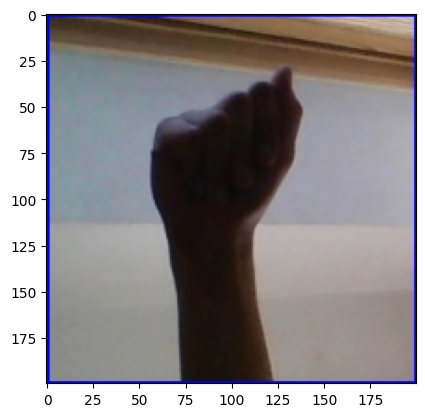

In [35]:
plt.imshow(test_img)

In [36]:
resized_img = cv2.resize(test_img, (64, 64))
rgb_img = cv2.cvtColor(resized_img, cv2.COLOR_BGR2RGB)
normalized_img = rgb_img.astype('float32') / 255.0
normalized_img.shape

(64, 64, 3)

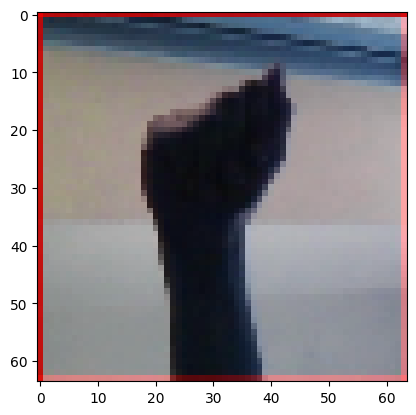

In [37]:
plt.imshow(normalized_img)

In [57]:
X_train = []
y_train = []
base_dir = 'asl_alphabet_train/asl_alphabet_train/'
for i in os.listdir(base_dir):
    folder_path = os.path.join(base_dir, i)
    all_images = os.listdir(folder_path)
    for j in all_images[:200]:
        image_path = os.path.join(folder_path, j)
        image = mpimg.imread(image_path)
        image_resize = cv2.resize(image, (64, 64))
        image_gray = cv2.cvtColor(image_resize, cv2.COLOR_RGB2GRAY)
        image_reshape = image_gray.reshape((64, 64, 1))
        image_normalize = image_reshape.astype('float32') / 255.0
        X_train.append(image_normalize)
        y_train.append(i)
X_train = np.array(X_train)
y_train = np.array(y_train)

In [39]:
X.shape

(2200, 64, 64, 1)

In [40]:
y.shape

(2200,)

In [41]:
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from keras.utils import to_categorical

In [42]:
label = LabelEncoder()
y = label.fit_transform(y)
y = to_categorical(y, num_classes = 29)

In [43]:
y.shape

(2200, 29)

In [44]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
X_train.shape

(1760, 64, 64, 1)

In [46]:
y_train.shape

(1760, 29)

In [51]:
from keras import Sequential
from keras.layers import MaxPooling2D, Dense, Flatten, Conv2D, Dropout
from keras.optimizers import Adam

In [52]:
model = Sequential()

model.add(Conv2D(filters = 32, kernel_size = (3, 3), activation = 'relu', input_shape = (64, 64, 1)))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Conv2D(filters = 64, kernel_size = (3, 3), activation = 'relu'))
model.add(MaxPooling2D(pool_size = (2, 2)))

model.add(Flatten())
model.add(Dense(units = 128, activation = 'relu'))
model.add(Dropout(0.5))
model.add(Dense(units = 29, activation = 'softmax'))

In [54]:
model.compile(Adam(learning_rate = 0.001), loss = 'categorical_crossentropy', metrics = ['accuracy'])

In [55]:
model.fit(X_train, y_train, epochs = 10, validation_data = (X_test, y_test), batch_size = 32)

Epoch 1/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 8s 87ms/step - accuracy: 0.1205 - loss: 2.7576 - val_accuracy: 0.2795 - val_loss: 2.2729
Epoch 2/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.3420 - loss: 1.9717 - val_accuracy: 0.7159 - val_loss: 1.2280
Epoch 3/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 80ms/step - accuracy: 0.5835 - loss: 1.3065 - val_accuracy: 0.8136 - val_loss: 0.7164
Epoch 4/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 71ms/step - accuracy: 0.7318 - loss: 0.8388 - val_accuracy: 0.9205 - val_loss: 0.4215
Epoch 5/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 74ms/step - accuracy: 0.8176 - loss: 0.5791 - val_accuracy: 0.9432 - val_loss: 0.2792
Epoch 6/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 72ms/step - accuracy: 0.8284 - loss: 0.4956 - val_accuracy: 0.9591 - val_loss: 0.1919
Epoch 7/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 78ms/step - accuracy: 0.8790 - loss: 0.3853 - val_accuracy: 0.9614 - val_loss: 0.1412
Epoch 8/10
55/55 ━━━━━━━━━━━━━━━━━━━━ 4s 73ms/step - accuracy: 0.9182 - loss: 0.2793 - val_accuracy: 0.9682 - v

In [64]:
ids = []
predictions = []
base_dir = 'asl_alphabet_test/asl_alphabet_test/'
for i in os.listdir(base_dir):
    test_images = os.path.join(base_dir, i)
    image = mpimg.imread(test_images)
    image_resize = cv2.resize(image, (64, 64))
    image_gray = cv2.cvtColor(image_resize, cv2.COLOR_RGB2GRAY)
    image_normalize = image_gray.astype('float32') / 255.0
    input_data = image_normalize.reshape(1, 64, 64, 1)
    pred = model.predict(input_data)
    label_index = np.argmax(pred)
    label_text = label.inverse_transform([label_index])[0]
    ids.append(i)
    predictions.append(label_text)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 93ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 54ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 58ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 67ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 60ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 57ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step
1/1 ━━━━━━━

In [65]:
submission = pd.DataFrame({
    'Id' : ids,
    'Label' : predictions
})

In [66]:
submission.to_csv('ASL_sub.csv', index = False)
submission.head()

,Id,Label
0,A_test.jpg,J
1,B_test.jpg,B
2,C_test.jpg,C
3,D_test.jpg,D
4,E_test.jpg,E


In [67]:
import pickle

In [68]:
model.save('asl_model.h5')

In [69]:
with open('label.pkl', 'wb') as file:
    pickle.dump(label, file)